In [2]:
# Mount Google Drive
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

drive.mount('/content/drive')

# Define project path in Drive
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
os.makedirs(PROJECT_PATH, exist_ok=True)

# Ensure subfolders exist
for sub in ["data/raw","data/processed","notebooks","results/eda_visualizations","results/output"]:
    os.makedirs(os.path.join(PROJECT_PATH, sub), exist_ok=True)

print("Project folder ready at:", PROJECT_PATH)


MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Dataset load
import pandas as pd
RAW_PATH = os.path.join(PROJECT_PATH, "data/raw/heart.csv")
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# mapping old names to new names
column_name_mapping = {
    'age': 'age',
    'sex': 'sex',
    'cp': 'chest_pain_type',
    'trestbps': 'resting_bp',
    'chol': 'cholesterol',
    'fbs': 'fasting_blood_sugar',
    'restecg': 'resting_ecg',
    'thalach': 'max_heart_rate',
    'exang': 'exercise_angina',
    'oldpeak': 'st_depression',
    'slope': 'st_slope',
    'ca': 'num_major_vessels',
    'thal': 'thalassemia',
    'target': 'heart_disease'
}

df.rename(columns=column_name_mapping, inplace=True)

# Display the new column names and the first few rows to confirm
print("New Column Names:")
print(df.columns.tolist())
print("\nFirst 3 rows of the renamed dataset:")
print(df.head(3))

New Column Names:
['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'st_depression', 'st_slope', 'num_major_vessels', 'thalassemia', 'heart_disease']

First 3 rows of the renamed dataset:
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_blood_sugar  \
0   52    1                0         125          212                    0   
1   53    1                0         140          203                    1   
2   70    1                0         145          174                    0   

   resting_ecg  max_heart_rate  exercise_angina  st_depression  st_slope  \
0            1             168                0            1.0         2   
1            0             155                1            3.1         0   
2            1             125                1            2.6         0   

   num_major_vessels  thalassemia  heart_disease  
0                  2            3              0  
1   

age                    0
sex                    0
chest_pain_type        0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
st_depression          0
st_slope               0
num_major_vessels      0
thalassemia            0
heart_disease          0
dtype: int64


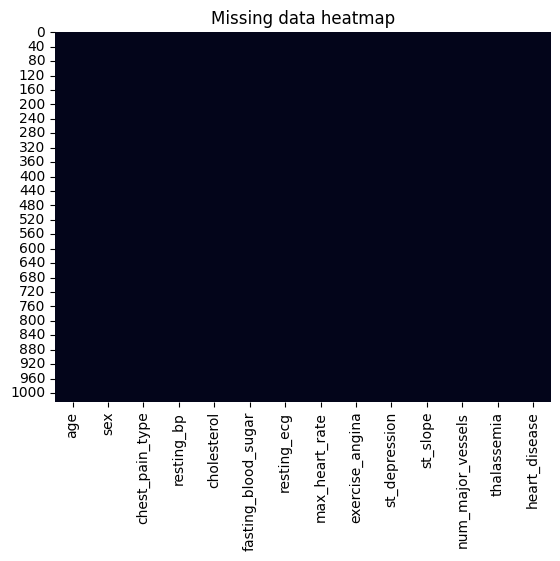

In [ ]:
# check missing values
print(df.isna().sum())
sns.heatmap(df.isnull(), cbar=False);
plt.title('Missing data heatmap');
plt.show()

In [ ]:
# Get comprehensive info
df.info()

# See specific data types
print("\nData Types:")
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1025 non-null   int64  
 1   sex                  1025 non-null   int64  
 2   chest_pain_type      1025 non-null   int64  
 3   resting_bp           1025 non-null   int64  
 4   cholesterol          1025 non-null   int64  
 5   fasting_blood_sugar  1025 non-null   int64  
 6   resting_ecg          1025 non-null   int64  
 7   max_heart_rate       1025 non-null   int64  
 8   exercise_angina      1025 non-null   int64  
 9   st_depression        1025 non-null   float64
 10  st_slope             1025 non-null   int64  
 11  num_major_vessels    1025 non-null   int64  
 12  thalassemia          1025 non-null   int64  
 13  heart_disease        1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Data Types:
age                      in

In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Select all numeric columns except target
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
numeric_features.remove('heart_disease')

# Create copies of dataset
df_scaled_standard = df.copy()
df_scaled_minmax = df.copy()

# Apply StandardScaler
scaler_standard = StandardScaler()
df_scaled_standard[numeric_features] = scaler_standard.fit_transform(df[numeric_features])

# Apply MinMaxScaler (0 to 1)
scaler_minmax = MinMaxScaler()
df_scaled_minmax[numeric_features] = scaler_minmax.fit_transform(df[numeric_features])

# Display first 5 rows for comparison
print("Original Data (first 5 rows):")
print(df[numeric_features].head(), "\n")

print("Standard Scaled Data (first 5 rows):")
print(df_scaled_standard[numeric_features].head(), "\n")

print("MinMax Scaled Data (first 5 rows):")
print(df_scaled_minmax[numeric_features].head())


Original Data (first 5 rows):
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_blood_sugar  \
0   52    1                0         125          212                    0   
1   53    1                0         140          203                    1   
2   70    1                0         145          174                    0   
3   61    1                0         148          203                    0   
4   62    0                0         138          294                    1   

   resting_ecg  max_heart_rate  exercise_angina  st_depression  st_slope  \
0            1             168                0            1.0         2   
1            0             155                1            3.1         0   
2            1             125                1            2.6         0   
3            1             161                0            0.0         2   
4            1             106                0            1.9         1   

   num_major_vessels  thalassemia  
0       

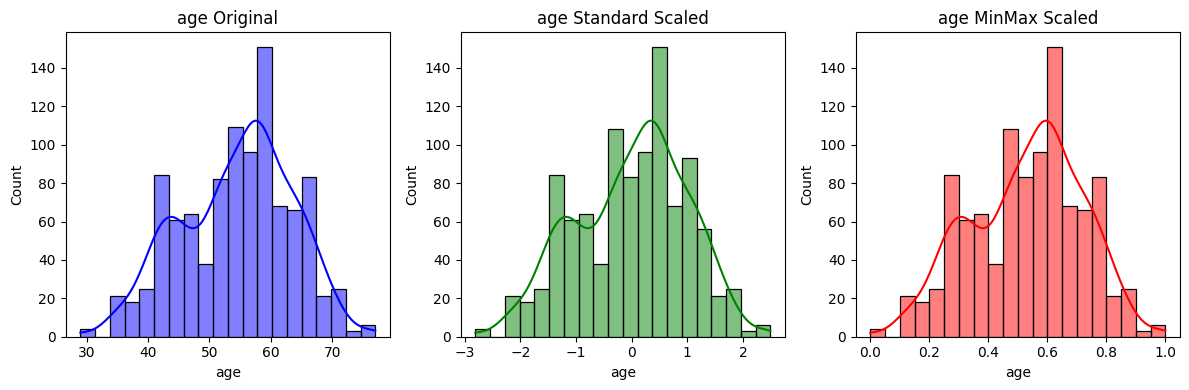

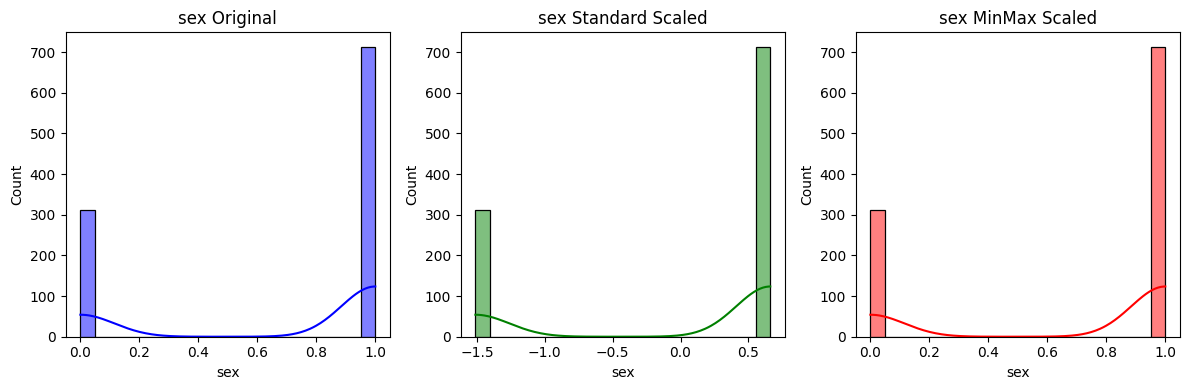

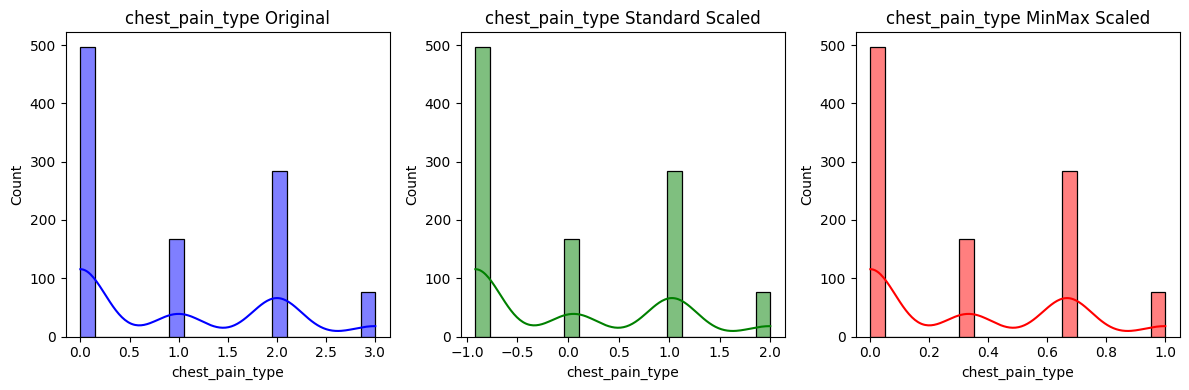

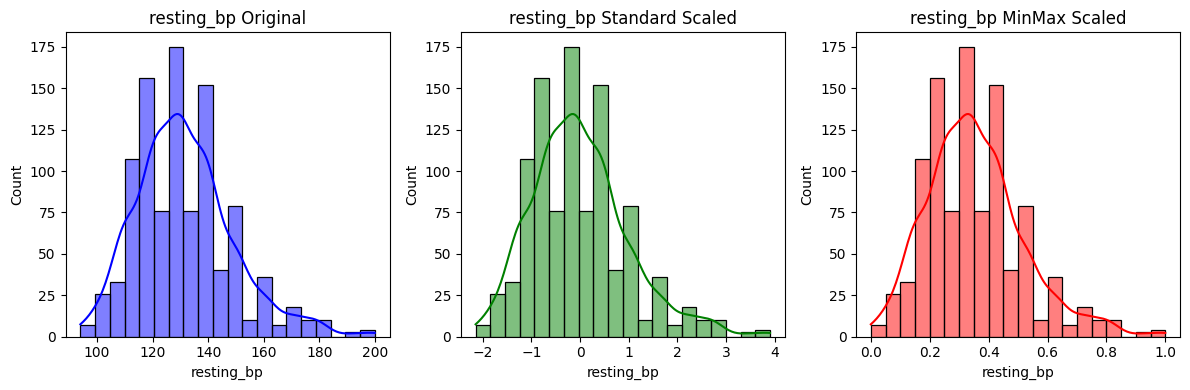

In [ ]:
# Visualization for multiple features

for col in numeric_features[:4]:  # show only first 4 to keep plots manageable
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    sns.histplot(df[col], bins=20, kde=True, color="blue")
    plt.title(f"{col} Original")

    plt.subplot(1,3,2)
    sns.histplot(df_scaled_standard[col], bins=20, kde=True, color="green")
    plt.title(f"{col} Standard Scaled")

    plt.subplot(1,3,3)
    sns.histplot(df_scaled_minmax[col], bins=20, kde=True, color="red")
    plt.title(f"{col} MinMax Scaled")

    plt.tight_layout()
    plt.show()

In [ ]:
# Final scaled dataset
df_final = df_scaled_standard.copy()

print("Final dataset ready for ML:", df_final.shape)
df_final.head()

Final dataset ready for ML: (1025, 14)


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
0,-0.268437,0.661504,-0.915755,-0.377636,-0.659332,-0.418878,0.891255,0.821321,-0.712287,-0.060888,0.995433,1.209221,1.089852,0
1,-0.158157,0.661504,-0.915755,0.479107,-0.833861,2.387330,-1.004049,0.255968,1.403928,1.727137,-2.243675,-0.731971,1.089852,0
2,1.716595,0.661504,-0.915755,0.764688,-1.396233,-0.418878,0.891255,-1.048692,1.403928,1.301417,-2.243675,-0.731971,1.089852,0
3,0.724079,0.661504,-0.915755,0.936037,-0.833861,-0.418878,0.891255,0.516900,-0.712287,-0.912329,0.995433,0.238625,1.089852,0
4,0.834359,-1.511706,-0.915755,0.364875,0.930822,2.387330,0.891255,-1.874977,-0.712287,0.705408,-0.624121,2.179817,-0.522122,0


In [ ]:
# Define save folder
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
SAVE_FOLDER = os.path.join(PROJECT_PATH, "results/eda_visualizations/feature_scaling")
os.makedirs(SAVE_FOLDER, exist_ok=True)

# Save plots
for col in numeric_features[:6]: #number of plots save
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    sns.histplot(df[col], bins=20, kde=True, color="blue")
    plt.title(f"{col} Original")

    plt.subplot(1,3,2)
    sns.histplot(df_scaled_standard[col], bins=20, kde=True, color="green")
    plt.title(f"{col} Standard Scaled")

    plt.subplot(1,3,3)
    sns.histplot(df_scaled_minmax[col], bins=20, kde=True, color="red")
    plt.title(f"{col} MinMax Scaled")

    plt.tight_layout()

    # Save each feature plot with its name
    plot_path = os.path.join(SAVE_FOLDER, f"{col}_scaling_comparison.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()
    print("Plot saved to:", plot_path)

print("All scaling comparison plots saved successfully.")


Plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/feature_scaling/age_scaling_comparison.png
Plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/feature_scaling/sex_scaling_comparison.png
Plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/feature_scaling/chest_pain_type_scaling_comparison.png
Plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/feature_scaling/resting_bp_scaling_comparison.png
Plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/feature_scaling/cholesterol_scaling_comparison.png
Plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/feature_scaling/fasting_blood_sugar_scaling_comparison.png
All scaling comparison plots saved successfully.


In [ ]:
# Updates .csv file save
df_final = df_scaled_standard.copy()

print("Final dataset ready for ML:", df_final.shape)

# Save processed dataset
PROC_PATH = os.path.join(PROJECT_PATH, "data/processed/IT24102753_scaled(1st).csv")
df_final.to_csv(PROC_PATH, index=False)
print("Saved scaled dataset to:", PROC_PATH)

Final dataset ready for ML: (1025, 14)
Saved scaled dataset to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/data/processed/IT24102753_scaled(1st).csv


In [3]:
drive.mount('/content/drive')

# Define project path in Drive
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
os.makedirs(PROJECT_PATH, exist_ok=True)

Mounted at /content/drive


In [5]:
# ==============================================================
# HEART FAILURE RISK PREDICTION – FULL MACHINE LEARNING PIPELINE
# ==============================================================

# Stage: Progress Review II & III
# Author: Group B11G1-01 | SLIIT | 2025
# --------------------------------------------------------------

# 🧩 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 🧠 2. LOAD DATASET
# Dataset load
import pandas as pd
RAW_PATH = os.path.join(PROJECT_PATH, "results/output/heart_dataset_final.csv")
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()
# --------------------------------------------------------------
# 🎯 3. FEATURE SELECTION AND TARGET SPLIT
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']




Dataset loaded: (1025, 12)


In [6]:
# --------------------------------------------------------------
# 🧮 4. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nData Split Completed:")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# --------------------------------------------------------------
# 📏 5. FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling applied.")

# --------------------------------------------------------------
# ⚙️ 6. MODEL DEFINITIONS & HYPERPARAMETER TUNING
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), {
        'C': [0.01, 0.1, 1, 10]
    }),
    "Decision Tree": (DecisionTreeClassifier(random_state=42), {
        'max_depth': [3, 5, 7, 9],
        'min_samples_split': [2, 5, 10]
    }),
    "SVM": (SVC(probability=True), {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    })
}

best_model = None
best_accuracy = 0
results = []

print("\n🔧 Starting Model Training & Tuning...")

for name, (model, params) in models.items():
    print(f"\nTraining {name}...")
    grid = GridSearchCV(model, params, cv=5)
    grid.fit(X_train_scaled if name != "Decision Tree" else X_train, y_train)

    y_pred = grid.predict(X_test_scaled if name != "Decision Tree" else X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{name} Accuracy: {acc:.4f}")
    print("Best Parameters:", grid.best_params_)
    print(classification_report(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Best Params": grid.best_params_
    })

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = grid.best_estimator_

# --------------------------------------------------------------
# 🏆 7. MODEL COMPARISON RESULTS
results_df = pd.DataFrame(results)
print("\n=== MODEL COMPARISON RESULTS ===")
print(results_df.sort_values(by='Accuracy', ascending=False))




Data Split Completed:
Training samples: 820
Testing samples: 205
Feature scaling applied.

🔧 Starting Model Training & Tuning...

Training Logistic Regression...
Logistic Regression Accuracy: 0.8439
Best Parameters: {'C': 1}
              precision    recall  f1-score   support

           0       0.90      0.76      0.83       100
           1       0.80      0.92      0.86       105

    accuracy                           0.84       205
   macro avg       0.85      0.84      0.84       205
weighted avg       0.85      0.84      0.84       205


Training Decision Tree...
Decision Tree Accuracy: 0.9756
Best Parameters: {'max_depth': 9, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       100
           1       0.98      0.97      0.98       105

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205


Tra


✅ Best Model Saved: SVC | Accuracy: 0.9805

=== MODEL EVALUATION SUMMARY ===
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
2                  SVM  0.980488   0.980662  0.980488  0.980481  0.998762   
1        Decision Tree  0.975610   0.975661  0.975610  0.975612  0.985143   
0  Logistic Regression  0.843902   0.851950  0.843902  0.842641  0.935810   

    CV Mean  
2  0.964634  
1  0.971951  
0  0.859756  


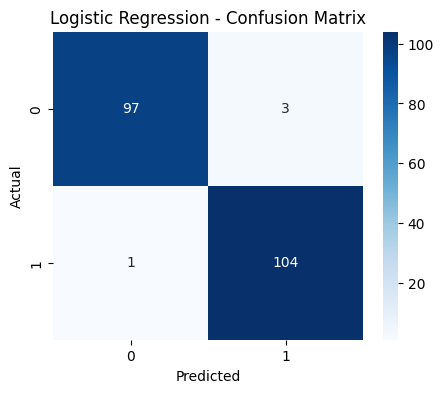

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


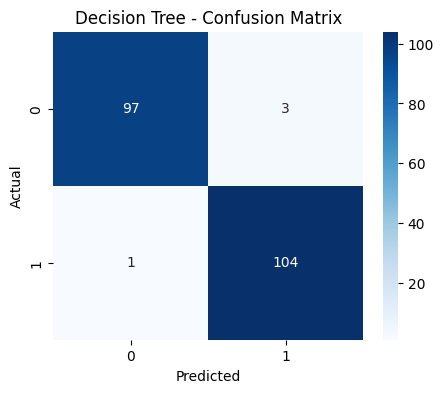

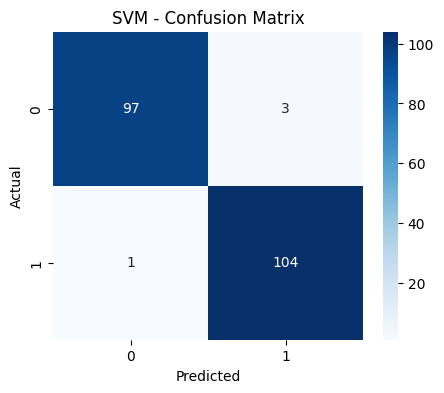

In [7]:
# Save best model & scaler
joblib.dump(best_model, "best_heart_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print(f"\n✅ Best Model Saved: {type(best_model).__name__} | Accuracy: {best_accuracy:.4f}")

# --------------------------------------------------------------
# 📊 8. MODEL EVALUATION & CROSS-VALIDATION
evaluation_results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, (model, params) in models.items():
    model = model.set_params(**params)
    grid = GridSearchCV(model, params, cv=5)
    grid.fit(X_train_scaled if name != "Decision Tree" else X_train, y_train)
    y_pred = grid.predict(X_test_scaled if name != "Decision Tree" else X_test)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    f1 = report['weighted avg']['f1-score']
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']

    if hasattr(grid.best_estimator_, "predict_proba"):
        y_prob = grid.best_estimator_.predict_proba(X_test_scaled if name != "Decision Tree" else X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan

    cv_scores = cross_val_score(grid.best_estimator_,
                                X_train_scaled if name != "Decision Tree" else X_train,
                                y_train, cv=cv)

    evaluation_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": auc,
        "CV Mean": np.mean(cv_scores)
    })

eval_df = pd.DataFrame(evaluation_results)
print("\n=== MODEL EVALUATION SUMMARY ===")
print(eval_df.sort_values(by="Accuracy", ascending=False))

# --------------------------------------------------------------
# 🧾 9. CONFUSION MATRICES
for name, (model, params) in models.items():
    model = grid.best_estimator_
    y_pred = model.predict(X_test_scaled if name != "Decision Tree" else X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



In [16]:
# --------------------------------------------------------------
# ❤️ 10. TEST MODEL WITH CUSTOM INPUT
print("\n=== TEST MODEL WITH YOUR OWN VALUES ===")

# Example patient data [age, sex, resting_bp, max_heart_rate, chest_pain_type,
# resting_ecg, st_depression, st_slope, exercise_angina, num_major_vessels, thalassemia]
# Example - Low Risk (No Heart Disease)
new_data = np.array([[35, 0, 120, 170, 0, 1, 0.0, 1, 0, 0, 2]])



# Load best model and scaler
model = joblib.load("best_heart_model.pkl")
scaler = joblib.load("scaler.pkl")

# Scale input and predict
new_data_scaled = scaler.transform(new_data)
prediction = model.predict(new_data_scaled)
probability = model.predict_proba(new_data_scaled)[0][1] if hasattr(model, "predict_proba") else None

if prediction[0] == 1:
    print(f"💔 High Risk of Heart Disease (Probability: {probability:.2f})")
else:
    print(f"💚 Low Risk of Heart Disease (Probability: {probability:.2f})")

print("\n✅ Model Training, Evaluation, and Testing Completed Successfully.")



=== TEST MODEL WITH YOUR OWN VALUES ===
💔 High Risk of Heart Disease (Probability: 0.54)

✅ Model Training, Evaluation, and Testing Completed Successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [18]:
# Load best model and scaler
model = joblib.load("best_heart_model.pkl")
scaler = joblib.load("scaler.pkl")

# New healthy patient (no heart disease expected)
new_data = np.array([[35, 0, 120, 170, 0, 1, 0.0, 1, 0, 0, 2]])

# Scale and predict
new_data_scaled = scaler.transform(new_data)
prediction = model.predict(new_data_scaled)
probability = model.predict_proba(new_data_scaled)[0][1]

if prediction[0] == 1:
    print(f"💔 High Risk of Heart Disease (Probability: {probability:.2f})")
else:
    print(f"💚 Low Risk of Heart Disease (Probability: {probability:.2f})")


💔 High Risk of Heart Disease (Probability: 0.54)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
